## Student Performance Indicator

##### Life Cycle of MachineLearning Project

* Understanding the problem statement 
* Data collection
* Data checks to perform 
* Exploratory Data Analysis
* Data preprocessing
* Model Training
* Choose best model

#### 1. Problem Statement

* This project understands how the student's performance (test score) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.

#### 2. Data Collection 

* Dataset source - https://laggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
* The data consists of 8 column and 1000 rows.

##### 2.1 Import Data and Required Packages 

Importing pandas, numpy, matplotlib, seaborn, warnings library

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
%matplotlib inline 
import warnings 
warnings.filterwarnings("ignore")

Import csv data as pandas DataFrame

In [2]:
df = pd.read_csv("data/stud.csv")

Show top 5 records

In [3]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Shape of the dataset 

In [4]:
df.shape

(1000, 8)

##### 2.2 Dataset information

* gender : sex of students -> (Male/Fenale)
* race/ ethnicity : ethnicity of students -> (Group A, B, C, D, E)
* parental level of education -> parent's final education -> (bachelor's degree, some college, master's degree, associate's degree, high school)
* lunch : having lunch before test (standard or free/ reduced)
* test preparation course : complete or not complete before test 
* math score 
* reading score 
*  writing score

#### 3. Data Checks to perform

* Check missing values 
* Check duplicates 
* Check data types 
* Check number of unique values of each column 
* Check statistics of dataset 
* Check various categories present in the different categorical columns 

##### 3.1 Checking missing values 

In [5]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

There are no missing values in the data set.

##### 3.2 Checking duplicates 

In [6]:
df.duplicated().sum()

np.int64(0)

There are no duplicates value in the dataset 

##### 3.3 Check data types 

In [7]:
#Check null and Dtypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


##### 3.4 Checking the number of unique values of each column

In [8]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

##### 3.5 Check statistics of dataset 

In [9]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


Insight : 
* From above description of numerical data, all means are very close to each other - i.e. between 66 and 68.05
* All standard deviations are also close - between 14.6 and 15.19
* While there is a minimum score 0 for math, for writing minimum score is much higher i.e. 0 and for reading, it is 17 

##### 3.6 Exploring data 

In [10]:
# Defining categorical and numeric columns 
numeric_features = [feature for feature in df.columns if df[feature].dtype != "str"]
categorical_features = [feature for feature in df.columns if df[feature].dtype == "str"]

In [11]:
print(f"There are {len(numeric_features)} numeric features : {numeric_features}")
print(f"There are {len(categorical_features)} categorical features : {categorical_features}")

There are 3 numeric features : ['math score', 'reading score', 'writing score']
There are 5 categorical features : ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [12]:
for feature in categorical_features : 
    # print(f"Categories in '{feature}' variable : {df[feature].unique()}")
    print(f"Categories in '{feature}' variable : {df[feature].unique().tolist()}")

Categories in 'gender' variable : ['female', 'male']
Categories in 'race/ethnicity' variable : ['group B', 'group C', 'group A', 'group D', 'group E']
Categories in 'parental level of education' variable : ["bachelor's degree", 'some college', "master's degree", "associate's degree", 'high school', 'some high school']
Categories in 'lunch' variable : ['standard', 'free/reduced']
Categories in 'test preparation course' variable : ['none', 'completed']


##### 3.7 Adding columns for "Total Score" and "Average"

In [15]:
df["total score"] = df["math score"] + df["reading score"] + df["writing score"]
df["average"] = df["total score"]/3

In [16]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [21]:
scores = ["math score" , "reading score" , "writing score"]

In [25]:
for score in scores :
    print(f"Number of students with 100% {score} is {df[df[score]==100][score].count()}") 
    print()
    

Number of students with 100% math score is 7

Number of students with 100% reading score is 17

Number of students with 100% writing score is 14



In [26]:
for score in scores :
    print(f"Number of students with less than 20 {score} is {df[df[score] <= 20][score].count()}") 
    print()

Number of students with less than 20 math score is 4

Number of students with less than 20 reading score is 1

Number of students with less than 20 writing score is 3



Insights : 
* From above values, we get that students have performed the worst in maths and best in reading section.

#### 4. Exploring data (Visualization)

##### 4.1 Visualize average score distribution to make some conclusions.

* Histogram 
* Kernel Distribution Function (KDE)

**4.1.1 Histogrma & KDE**

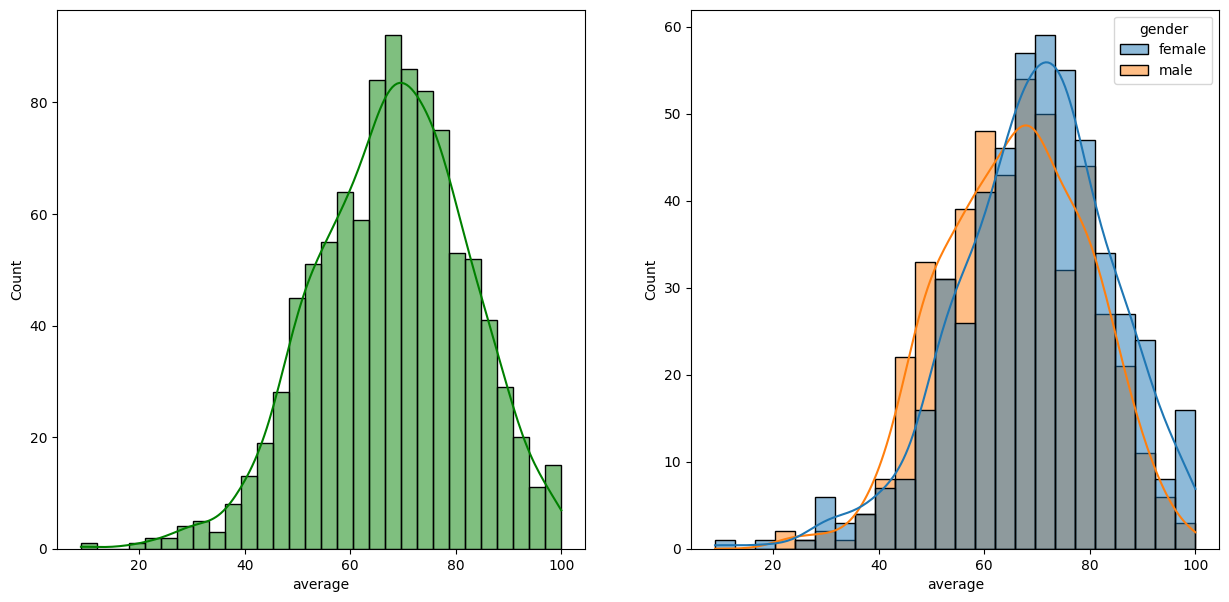

In [27]:
fig, axs = plt.subplots(1, 2, figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df, x="average", bins=30, kde=True, color="g")
plt.subplot(122)
sns.histplot(data=df, x="average", kde=True, hue="gender")
plt.show()


Insight : 
* Female students tend to perform well than male students.

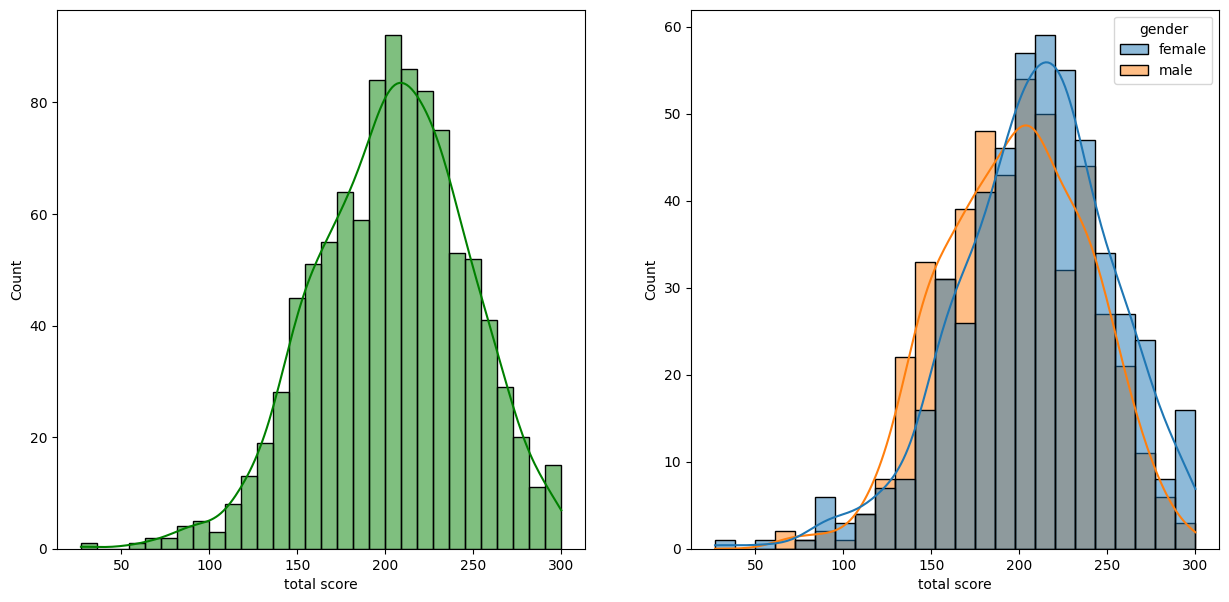

In [30]:
fig, axs = plt.subplots(1, 2, figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df, x="total score", bins=30, kde=True, color="g")
plt.subplot(122)
sns.histplot(data=df, x="total score", kde=True, hue="gender")
plt.show()

Insight : 
* Female students tend to perform well than male students.

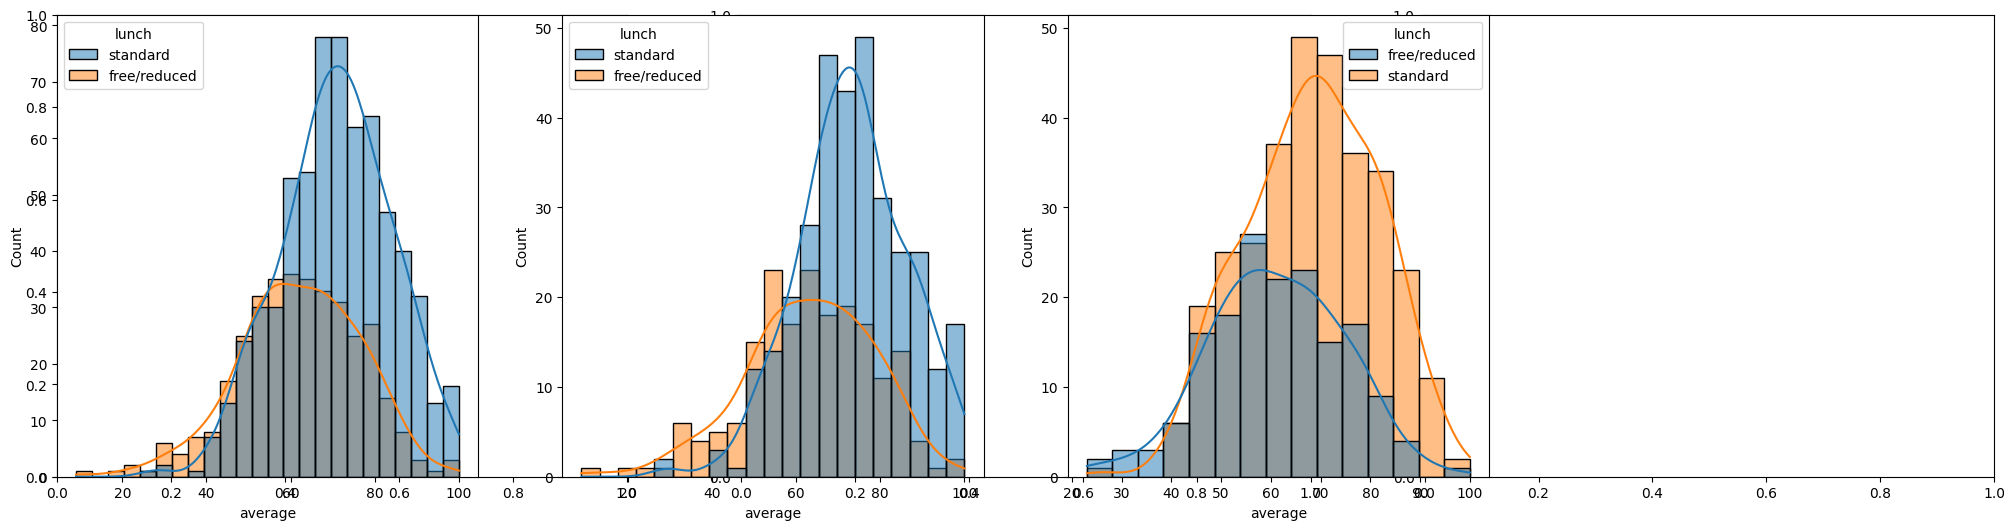

In [29]:
plt.subplots(1, 3, figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df , x= "average" , kde=True , hue="lunch")
plt.subplot(142)
sns.histplot(data= df[df.gender=="female"], x="average", kde=True, hue="lunch")
plt.subplot(143)
sns.histplot(data=df[df["gender"]=="male"], x="average", kde=True, hue="lunch")
plt.show()

Insight : 
* Standard lunch helps to perform well in exams, whether it is male or a female.

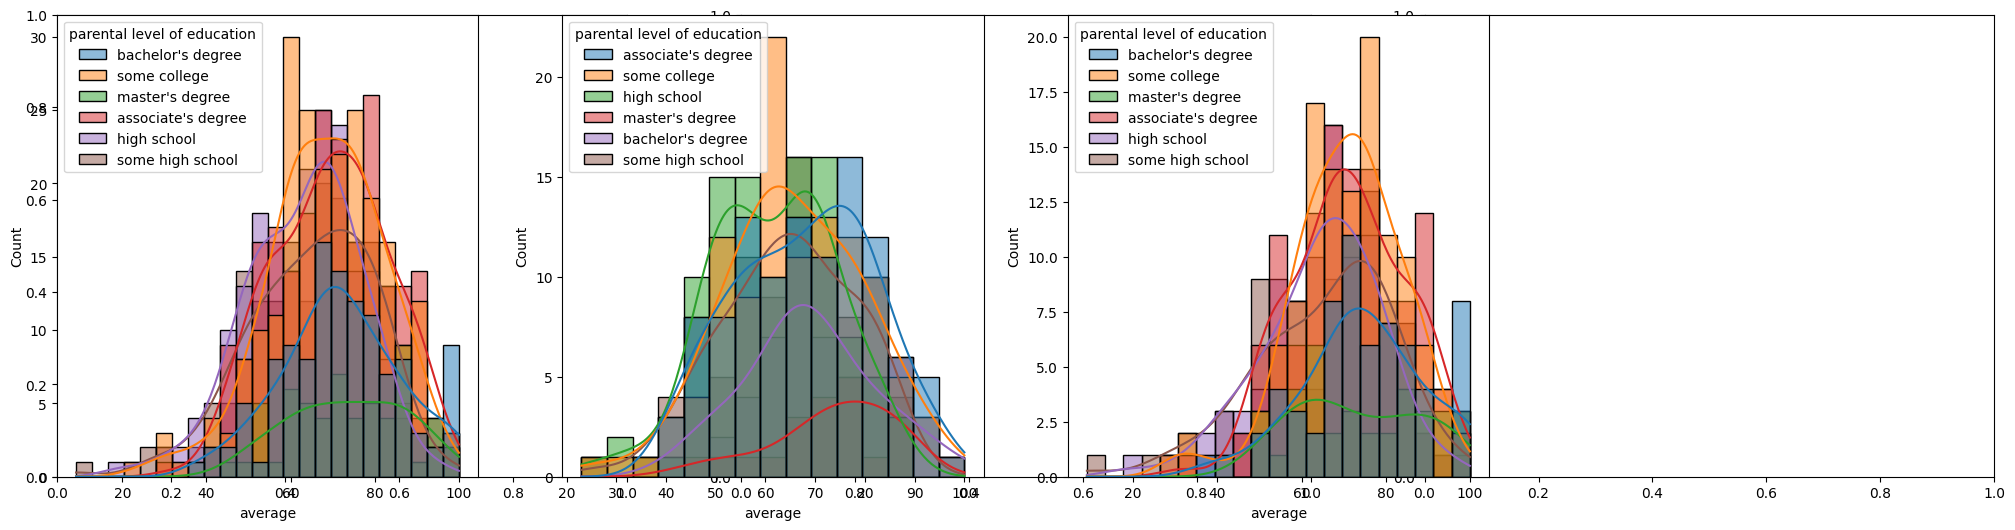

In [32]:
plt.subplots(1, 3, figsize=(25,6))
plt.subplot(141)
ax = sns.histplot(data=df, x="average", kde=True, hue="parental level of education")
plt.subplot(142)
ax = sns.histplot(data=df[df["gender"]=="male"], x="average", kde=True, hue="parental level of education")
plt.subplot(143)
ax = sns.histplot(data=df[df["gender"]=="female"], x="average", kde=True, hue="parental level of education")
plt.show()

Insights : 
* In general, parent's education level don't help student perform well in exam. 
* 2nd plot shows that parent's whose education is of associate's degree or master's degree, their male child performs well in exam. 
* In 3rd plot, we can see there is no effect of parent's education on female students.

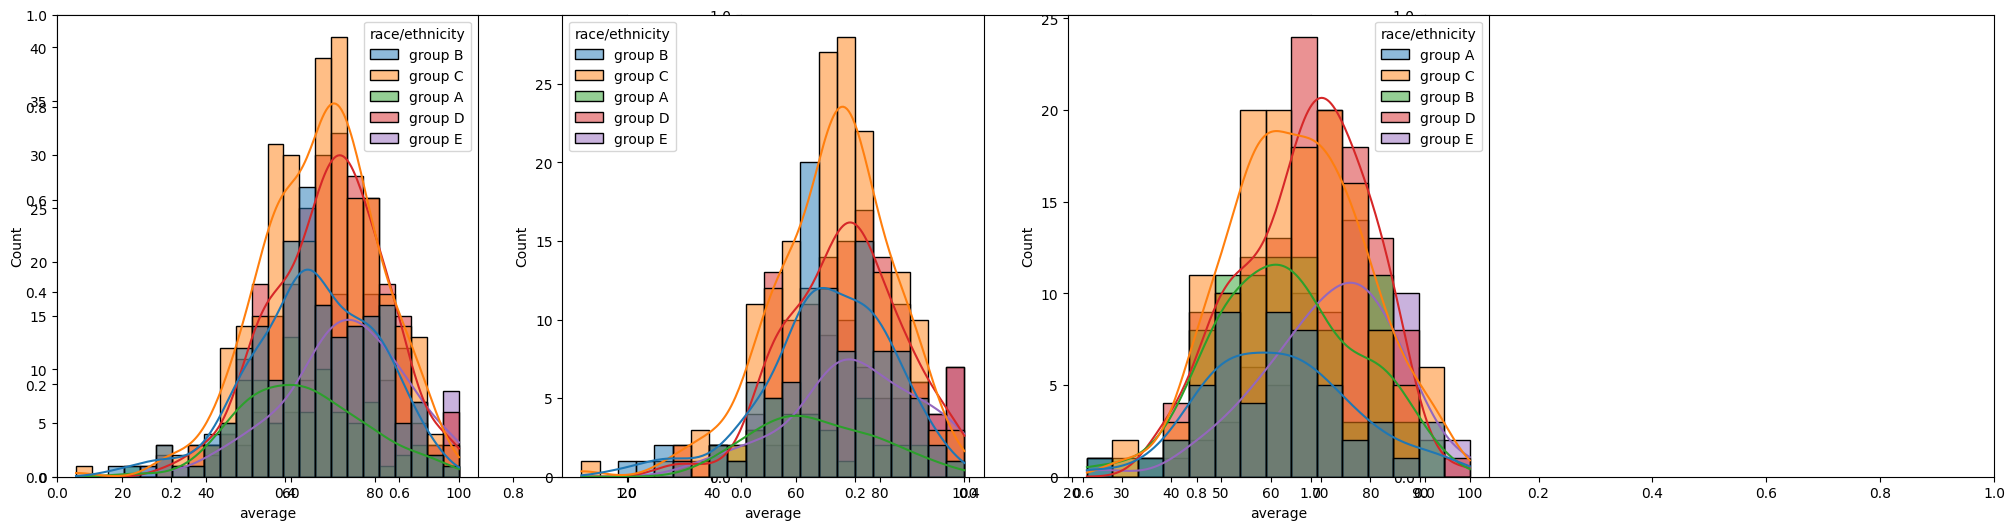

In [34]:
plt.subplots(1, 3, figsize=(25,6))
plt.subplot(141)
ax = sns.histplot(data=df, x="average", kde=True, hue="race/ethnicity")
plt.subplot(142)
ax = sns.histplot(data=df[df["gender"]=="female"], x="average", kde=True, hue="race/ethnicity")
plt.subplot(143)
ax = sns.histplot(data=df[df["gender"]=="male"], x="average", kde=True, hue="race/ethnicity")
plt.show()

Insights : 
* Students of group A and group B tends to perform poorly in exam. 
* Students of group A and group B tends to perform poorly in exams irrespective of whether they are male or female. 

##### 4.2 Maximum score of students in all 3 subjects 

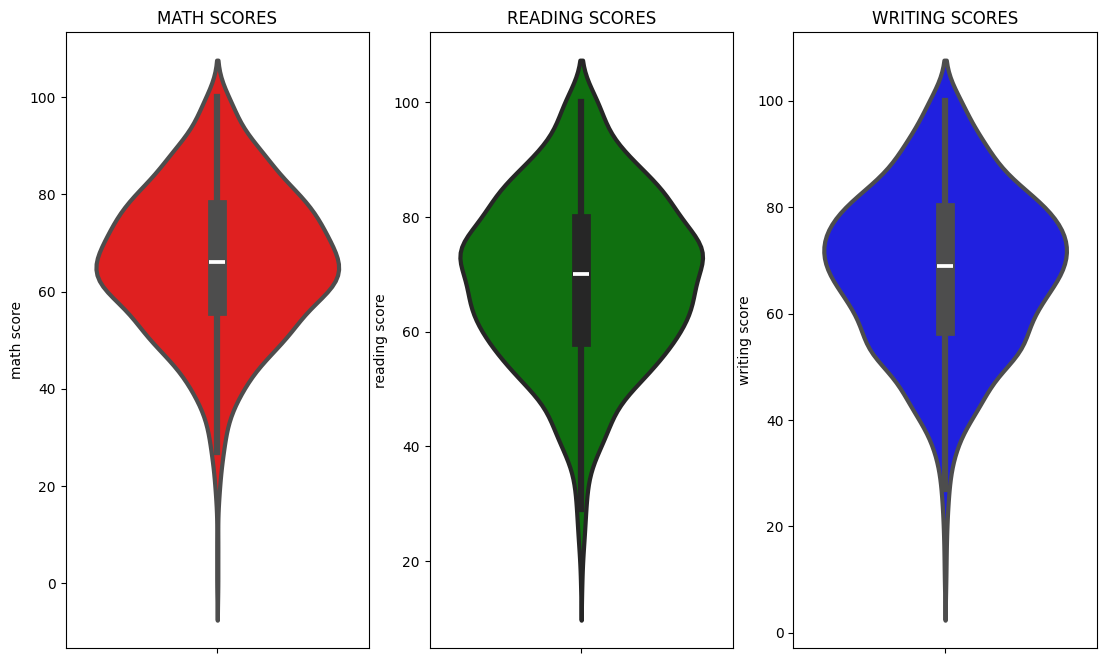

In [35]:
plt.figure(figsize=(18,8))
plt.subplot(141)
plt.title("MATH SCORES")
sns.violinplot(y="math score", data=df, color="red", linewidth=3)
plt.subplot(142)
plt.title("READING SCORES")
sns.violinplot(y="reading score", data=df, color="green", linewidth=3)
plt.subplot(143)
plt.title("WRITING SCORES")
sns.violinplot(y="writing score", data=df, color="blue", linewidth=3)
plt.show()

Insights : 
* From the above three plots, its clearly visible that most of the students score in between 60-80 in Maths whereas in reading and writing, most of them score from 50-80

##### 4.3 Multivariate analysis using pieplot 

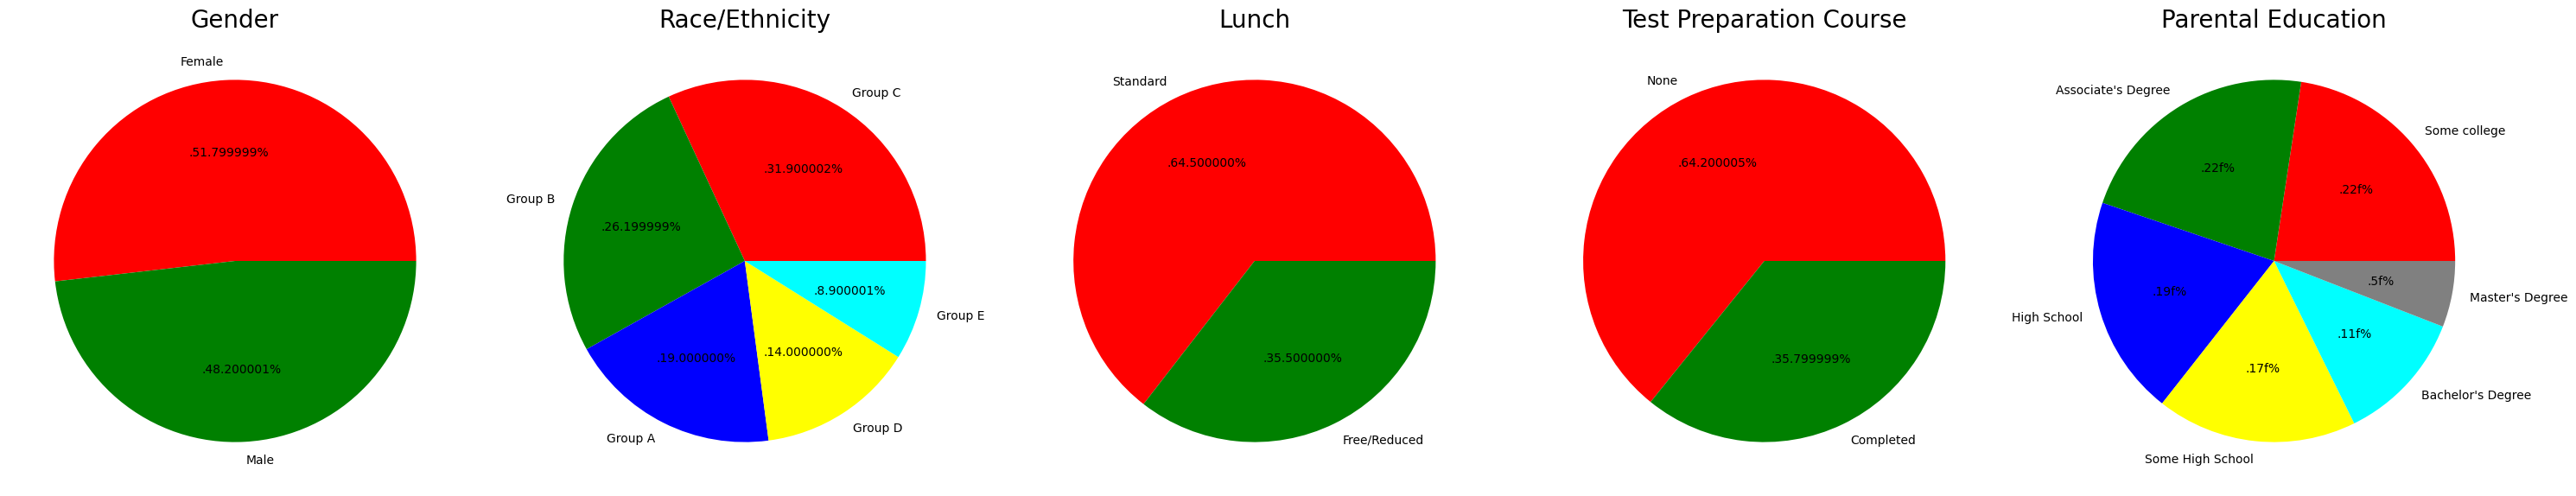

In [39]:
plt.rcParams["figure.figsize"] = (30,12)

plt.subplot(151)
size = df["gender"].value_counts()
labels = "Female","Male"
color = ["red", "green"]

plt.pie(size, colors=color, labels=labels, autopct=".%2f%%")
plt.title("Gender", fontsize=20)
plt.axis("off")

plt.subplot(152)
size = df["race/ethnicity"].value_counts()
labels = "Group C","Group B","Group A","Group D","Group E"
color = ["red", "green", "blue", "yellow", "cyan"]

plt.pie(size, colors=color, labels=labels, autopct=".%2f%%")
plt.title("Race/Ethnicity", fontsize=20)
plt.axis("off")

plt.subplot(153)
size = df["lunch"].value_counts()
labels = "Standard","Free/Reduced"
color = ["red", "green"]

plt.pie(size, colors=color, labels=labels, autopct=".%2f%%")
plt.title("Lunch", fontsize=20)
plt.axis("off")

plt.subplot(154)
size = df["test preparation course"].value_counts()
labels = "None","Completed"
color = ["red", "green"]

plt.pie(size, colors=color, labels=labels, autopct=".%2f%%")
plt.title("Test Preparation Course", fontsize=20)
plt.axis("off")

plt.subplot(155)
size = df["parental level of education"].value_counts()
labels = "Some college", "Associate's Degree", "High School", "Some High School", "Bachelor's Degree", "Master's Degree"
color = ["red" , "green" , "blue" , "yellow" , "cyan" , "grey"]

plt.pie(size, colors=color, labels=labels, autopct=".%df%%")
plt.title("Parental Education", fontsize=20)
plt.axis("off")

plt.tight_layout()
plt.grid()

plt.show()

Insights : 
* Number of Male and Female students is almost equal.
* Number of students are highest in Group C.
* Number of students who have standard lunch are greater.
* Number of students who have not enrolled in any test preparation course is greater.
* Number of students whose parental education is "Some College" is greater, followed closely by "Associate's Degree"

##### 4.4 Feature Wise Visualization


**4.4.1 GENDER COLUMN**

* How is distribution of Gender?
* Does gender has any impact on student's performance?

**UNIVARIATE ANALYSIS (How is distribution of Gender?)**

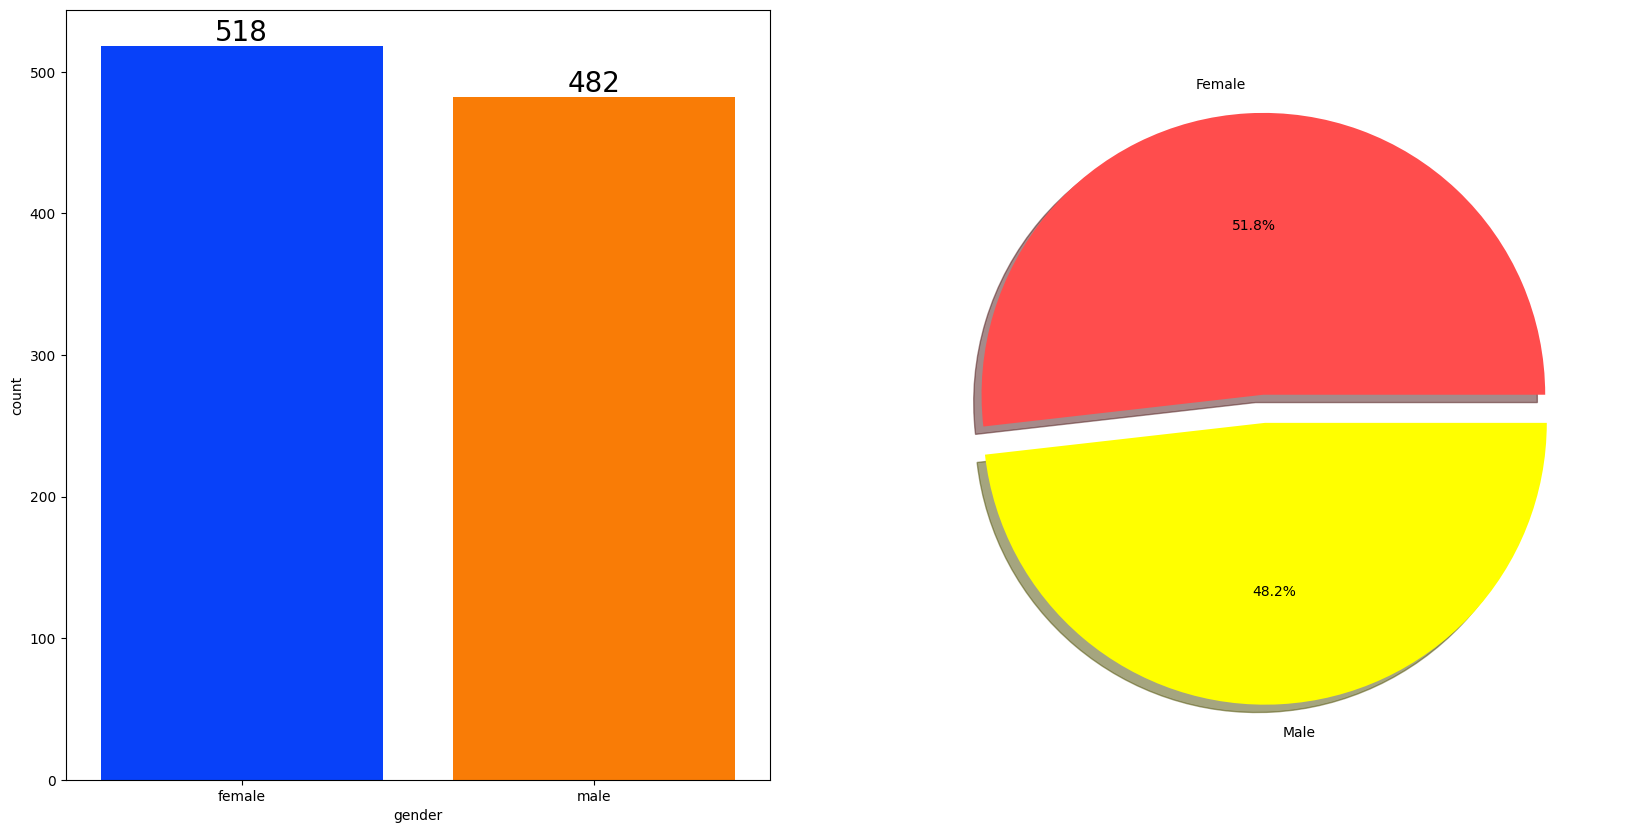

In [42]:
f, ax = plt.subplots(1,2, figsize=(20,10))
sns.countplot(x=df["gender"], data=df, palette="bright", ax=ax[0], saturation=0.95)
for container in ax[0].containers : 
    ax[0].bar_label(container, color="black", size=20)

plt.pie(x=df["gender"].value_counts(), labels=["Female", "Male"], explode=[0,0.1], autopct='%1.1f%%', shadow=True, colors=["#ff4d4d","yellow"])
plt.show()


Insights : 
* Gender has balanced data having 518 femake students (52%) and 482 male students (48%)

**BIVARIATE ANALYSIS (Does gender has any impact on student's performance?)**

In [46]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score', 'total score', 'average'],
      dtype='str')

In [47]:
gender_group = df[["math score", "reading score", "writing score", "total score", "average"]].groupby(df["gender"]).mean()
gender_group

,math score,reading score,writing score,total score,average
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


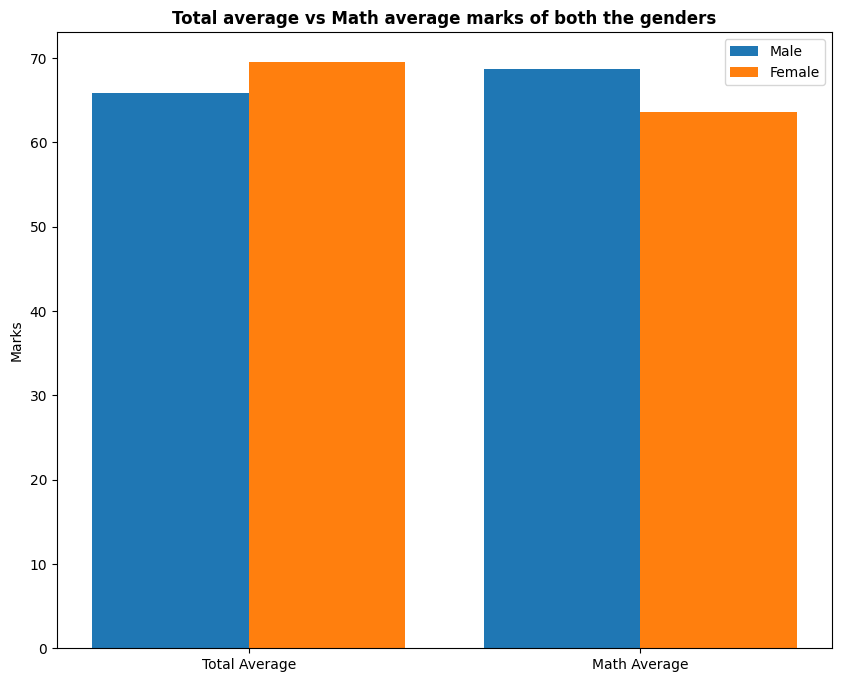

In [49]:
plt.figure(figsize=(10,8))

x = ["Total Average", "Math Average"]

female_scores = [ gender_group["average"]["female"] , gender_group["math score"]["female"] ]
male_scores = [ gender_group["average"]["male"] , gender_group["math score"]["male"] ]

x_axis = np.arange(len(x))

plt.bar(x_axis-0.2 , male_scores , 0.4 , label="Male")
plt.bar(x_axis+0.2 , female_scores , 0.4 , label="Female")

plt.xticks(x_axis, x)
plt.ylabel("Marks")
plt.title("Total average vs Math average marks of both the genders", fontweight="bold")
plt.legend()
plt.show()

Insights : 
* On an average, females have a better score than men.
* whereas, males have scored higher in maths.

**4.4.2 RACE/ETHNICITY COLUMN**

* How is Group wise distribution? 
* Is race/ethnicity having any impact on student's performance?

**UNIVARIATE ANALYSIS (How is Group wise distribution?)**

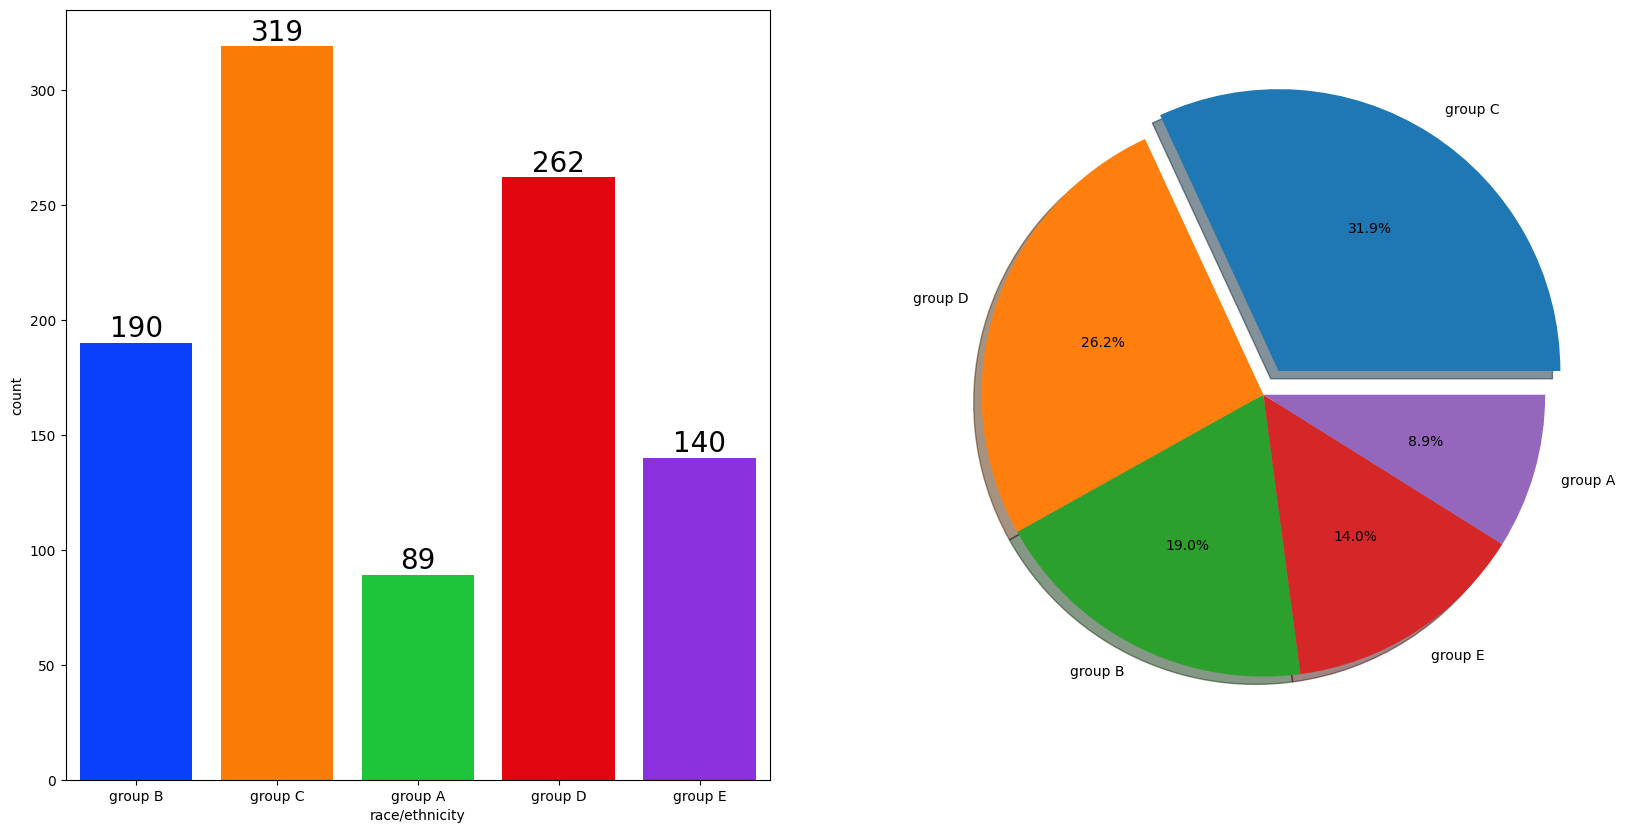

In [50]:
f, ax = plt.subplots(1,2, figsize=(20,10))
sns.countplot(x=df["race/ethnicity"], data=df, palette="bright", ax=ax[0], saturation=0.95)
for container in ax[0].containers : 
    ax[0].bar_label(container, color="black", size=20)

plt.pie(x=df["race/ethnicity"].value_counts(), labels=df["race/ethnicity"].value_counts().index, explode=[0.1,0,0,0,0], autopct='%1.1f%%', shadow=True)
plt.show()

Insights : 
* Most of the students belong to group C /  group D
* Least number of students belong to group A 

**BIVARIATE ANALYSIS (Is race/ethnicity having any impact on student's performance?)**

In [58]:
race_group = df[["math score", "reading score", "writing score", "total score", "average"]].groupby(df["race/ethnicity"]).mean()
race_group

,math score,reading score,writing score,total score,average
race/ethnicity,,,,,
group A,61.629213,64.674157,62.674157,188.977528,62.992509
group B,63.452632,67.352632,65.600000,196.405263,65.468421
group C,64.463950,69.103448,67.827586,201.394984,67.131661
group D,67.362595,70.030534,70.145038,207.538168,69.179389
group E,73.821429,73.028571,71.407143,218.257143,72.752381


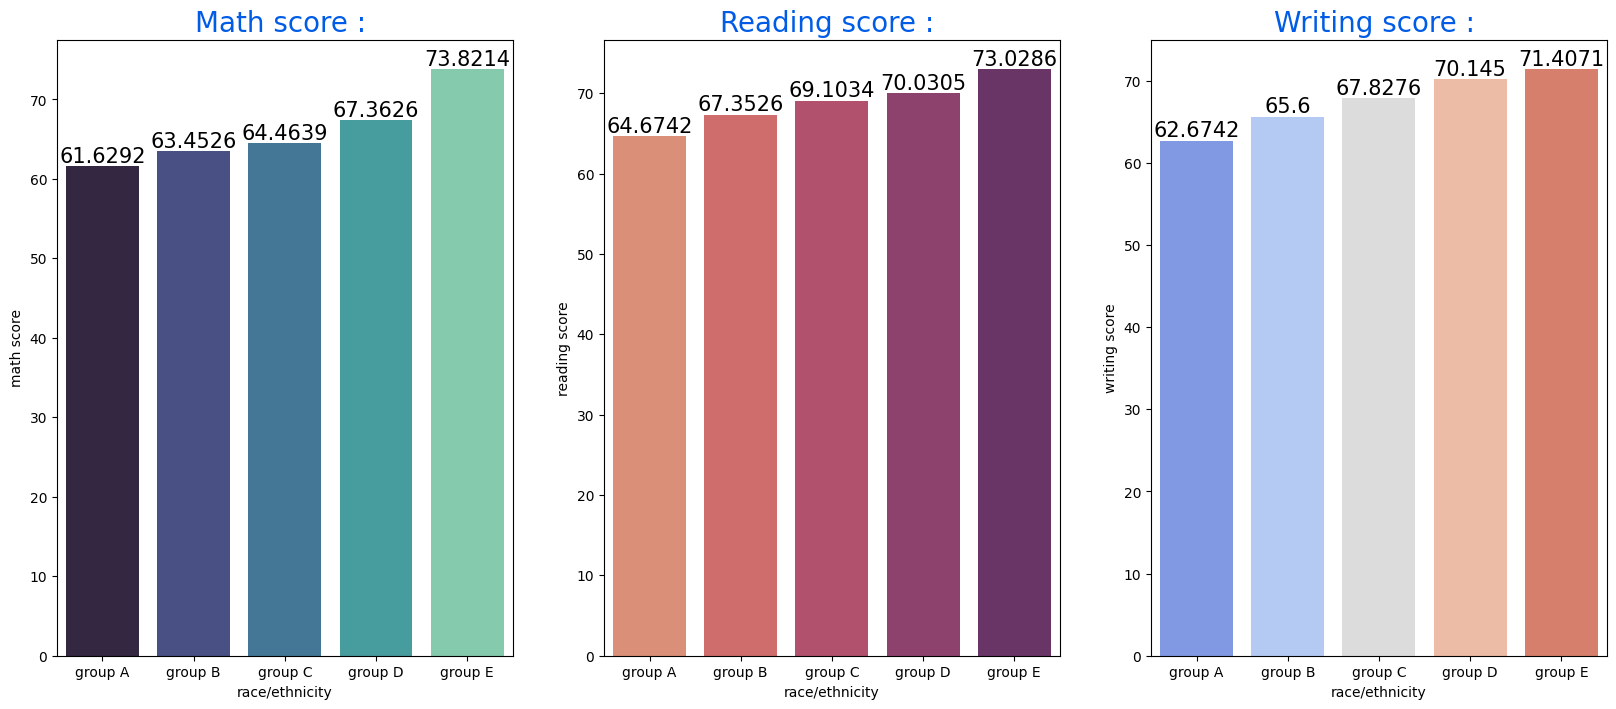

In [64]:
f, ax = plt.subplots(1,3, figsize=(20,8))
sns.barplot(x=race_group["math score"].index, y=race_group["math score"], palette="mako", ax=ax[0])
ax[0].set_title("Math score : ", color="#005ce6", size=20)

for container in ax[0].containers:
    ax[0].bar_label(container, color="black", size=15)

sns.barplot(x=race_group["reading score"].index, y=race_group["reading score"], palette="flare", ax=ax[1])
ax[1].set_title("Reading score : ", color="#005ce6", size=20)

for container in ax[1].containers:
    ax[1].bar_label(container, color="black", size=15)

sns.barplot(x=race_group["writing score"].index, y=race_group["writing score"], palette="coolwarm", ax=ax[2])
ax[2].set_title("Writing score : ", color="#005ce6", size=20)

for container in ax[2].containers : 
    ax[2].bar_label(container, color="black", size=15)


Insights : 
* Group E students have scored the highest marks. 
* Group A students have scored the lowest marks.
* Students from a lower socioeconomic status have a lower avg in all course subjects.

**PARENTAL LEVEL OF EDUCATION COLUMN**

* What is educational background of student's parent? 
* Is parental education having any impact on student's performance?

**UNIVARIATE ANALYSIS (What is educational background of student's parents)**

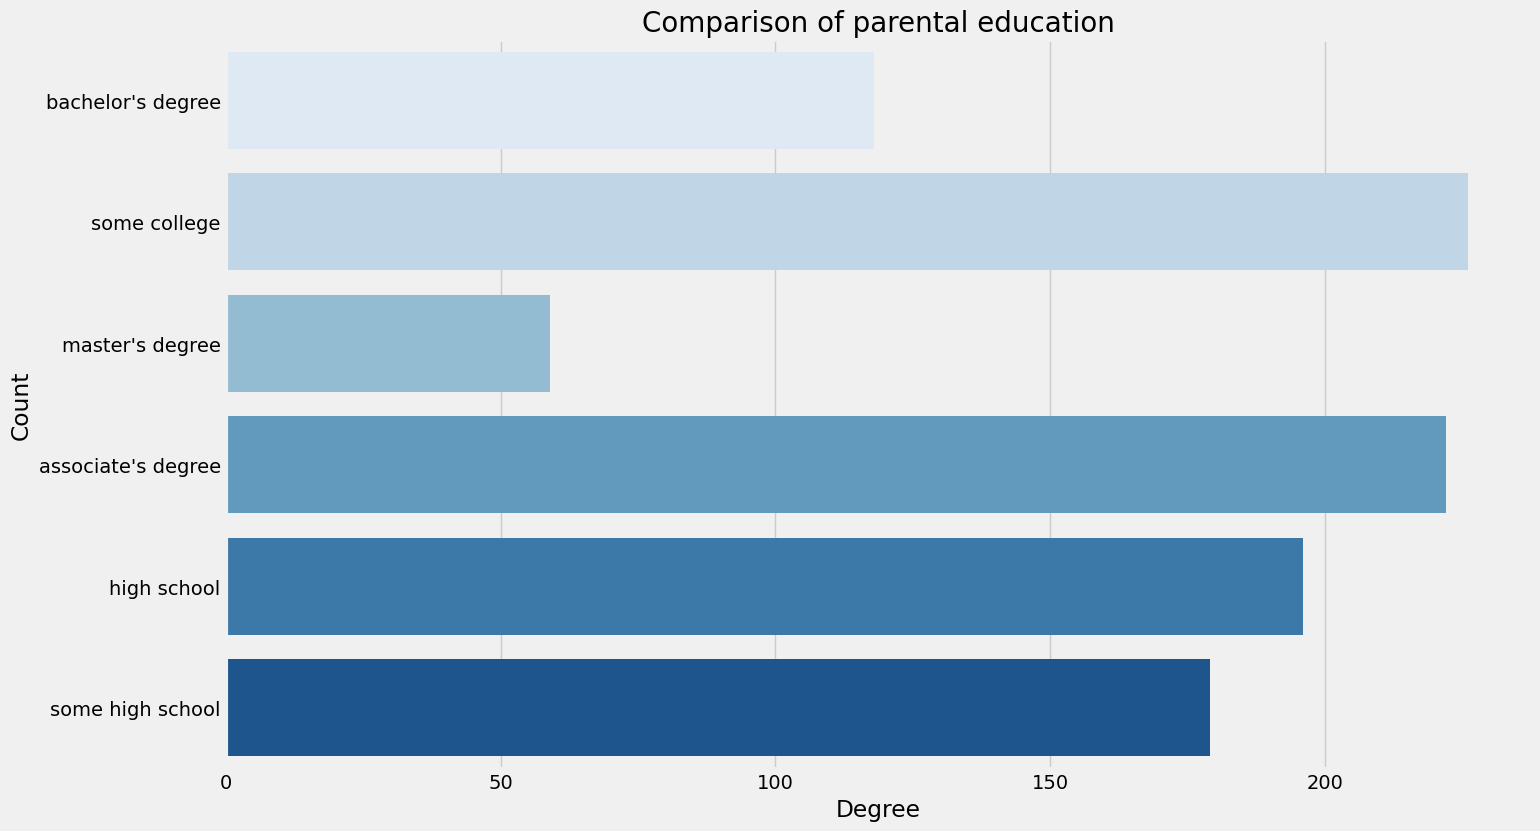

In [65]:
plt.rcParams["figure.figsize"] = (15,9)
plt.style.use("fivethirtyeight")
sns.countplot(df["parental level of education"], palette="Blues")
plt.title("Comparison of parental education", fontweight=30, fontsize=20)
plt.xlabel("Degree")
plt.ylabel("Count")
plt.show()

Insights : 
* Largest number of parents are from some college.

**BIVARIATE ANALYSIS (Is parental education having any impact on student's performance?)**

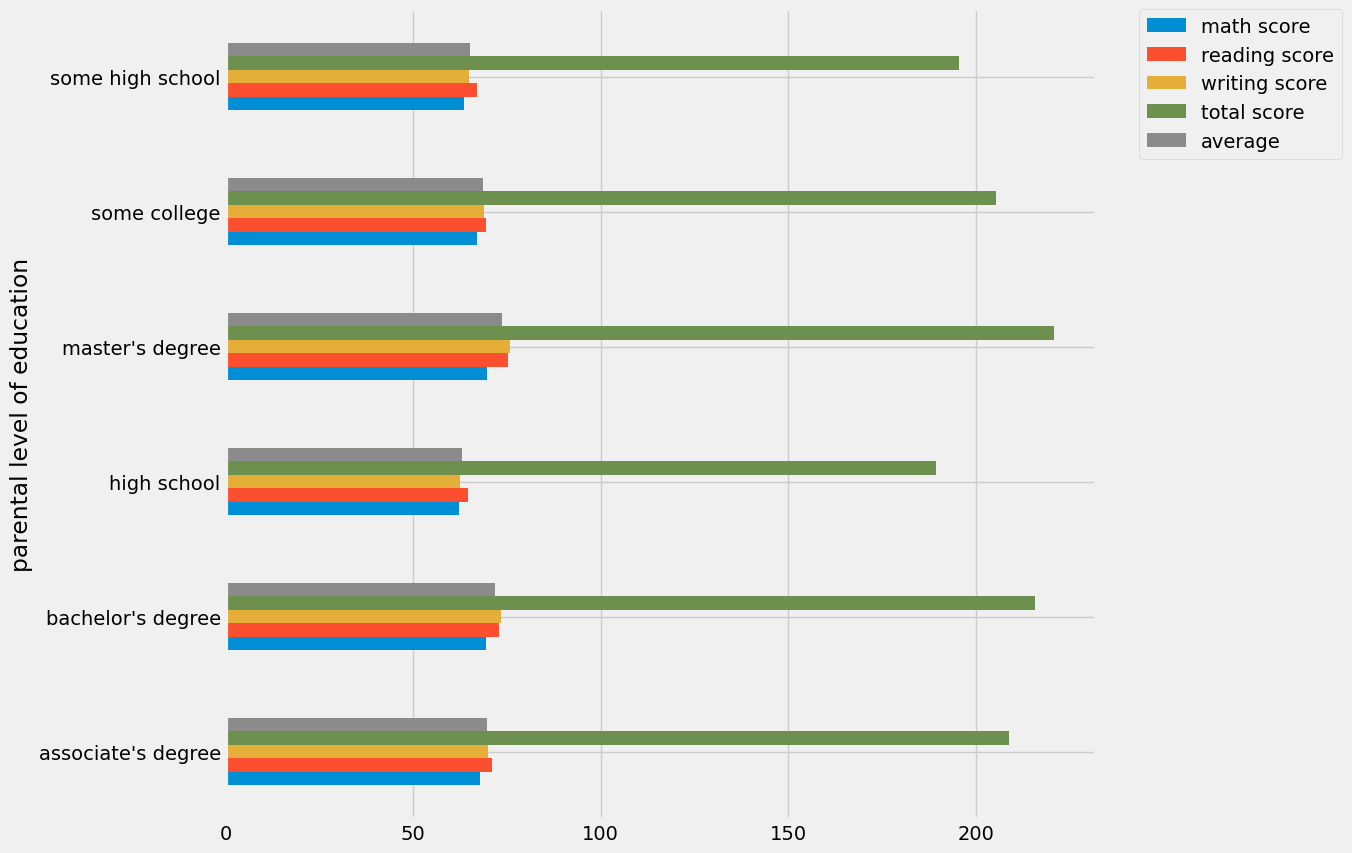

In [70]:
df.groupby("parental level of education")[["math score", "reading score", "writing score", "total score", "average"]].mean().plot(kind="barh", figsize=(10,10))
plt.legend(bbox_to_anchor=(1.05,1), loc=2, borderaxespad=0.)
plt.show()

Insights : 
* The score of student whose parents possess master and bachelor level education are higher than others.

**4.4.4 LUNCH COLUMN**

* Which type of lunch is most common among students? 
* What is the effect of lunch type on test results? 

**UNIVARIATE ANALYSIS (Which type of lunch is most common among students?)**

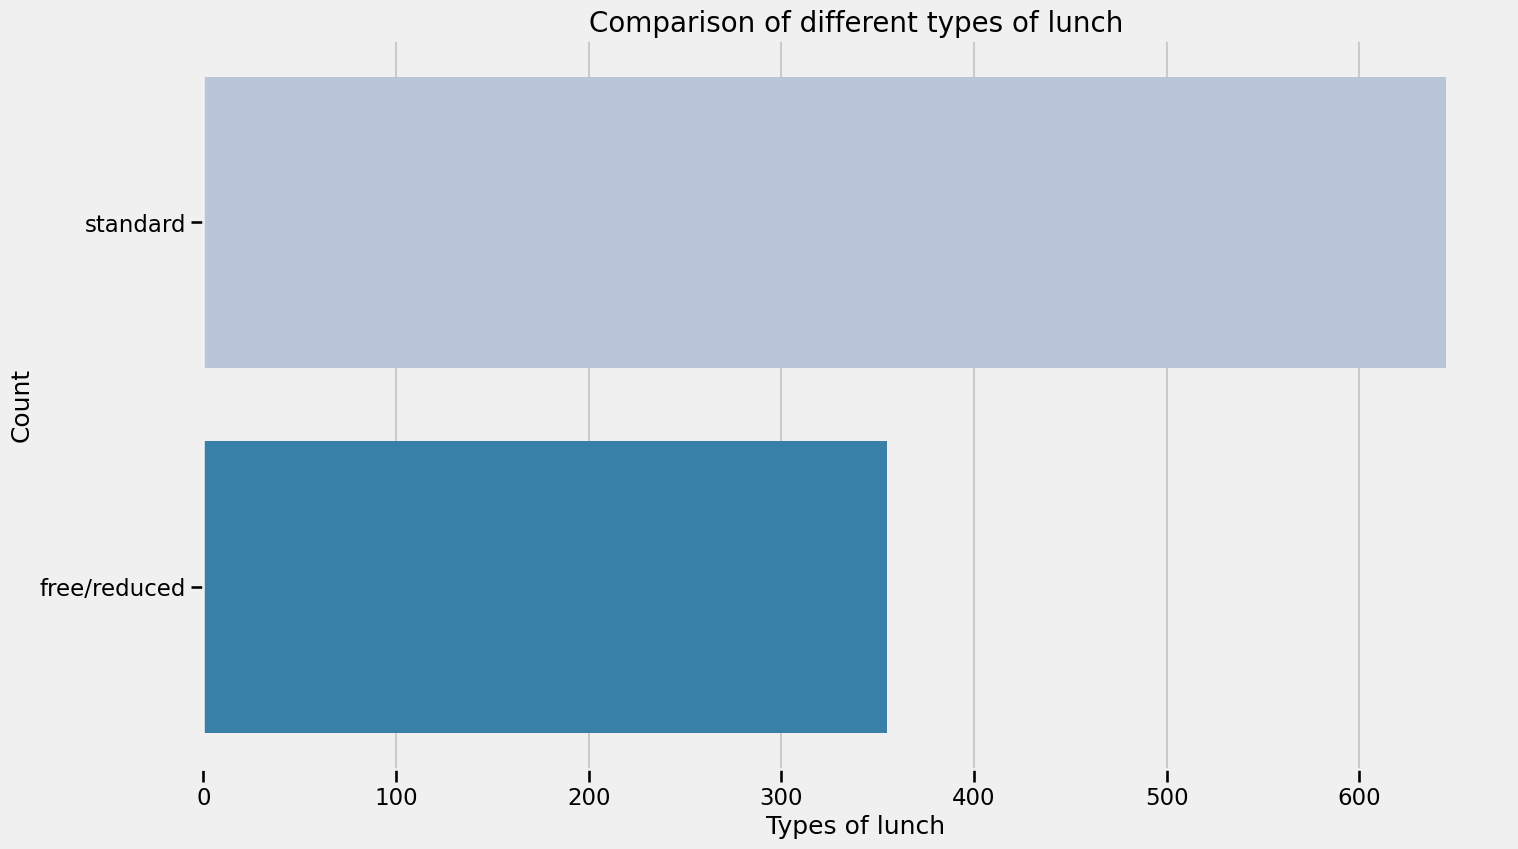

In [73]:
plt.rcParams["figure.figsize"] = (15,9)
sns.set_context('talk')
sns.countplot(df["lunch"], palette="PuBu")
plt.title("Comparison of different types of lunch", fontweight=30, fontsize=20)
plt.xlabel("Types of lunch")
plt.ylabel("Count")
plt.show()

Insights : 
* Students being served standard lunch was more in number than student having free/reduced lunch.

**BIVARIATE ANALYSIS (Is lunch type intake having any impact on student's performance?)**

In [74]:
lunch_group = df[["math score", "reading score", "writing score", "total score", "average"]].groupby(df["lunch"]).mean()
lunch_group

,math score,reading score,writing score,total score,average
lunch,,,,,
free/reduced,58.921127,64.653521,63.022535,186.597183,62.199061
standard,70.034109,71.654264,70.823256,212.511628,70.837209


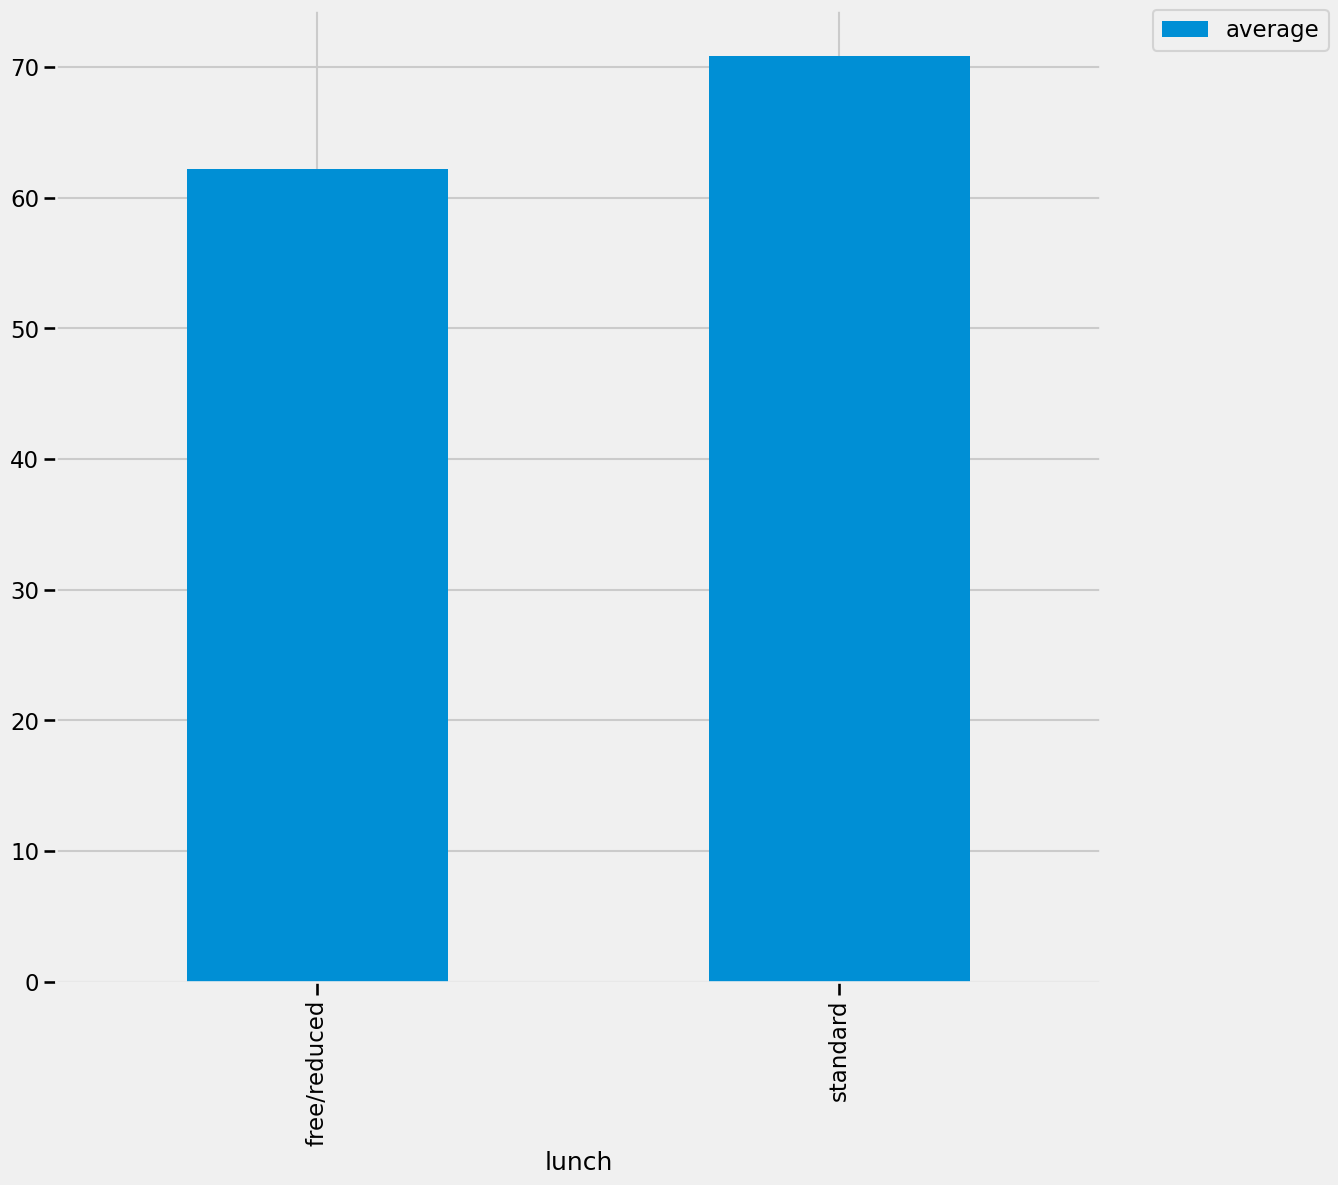

In [81]:
df.groupby("lunch")[["average"]].mean().plot(kind="bar", figsize=(12,12))
plt.legend(bbox_to_anchor=(1.05,1), loc=2, borderaxespad=0.)
plt.show()

Insight : 
* Students having stnadard lunch score higher.

**4.4.5 TEST PREPARATION COURSE COLUMN**

* Which type of test preparation course is most common among students?
* Is test preparation course having any impact on student's performance?

**UNIVARIATE ANALYSIS**

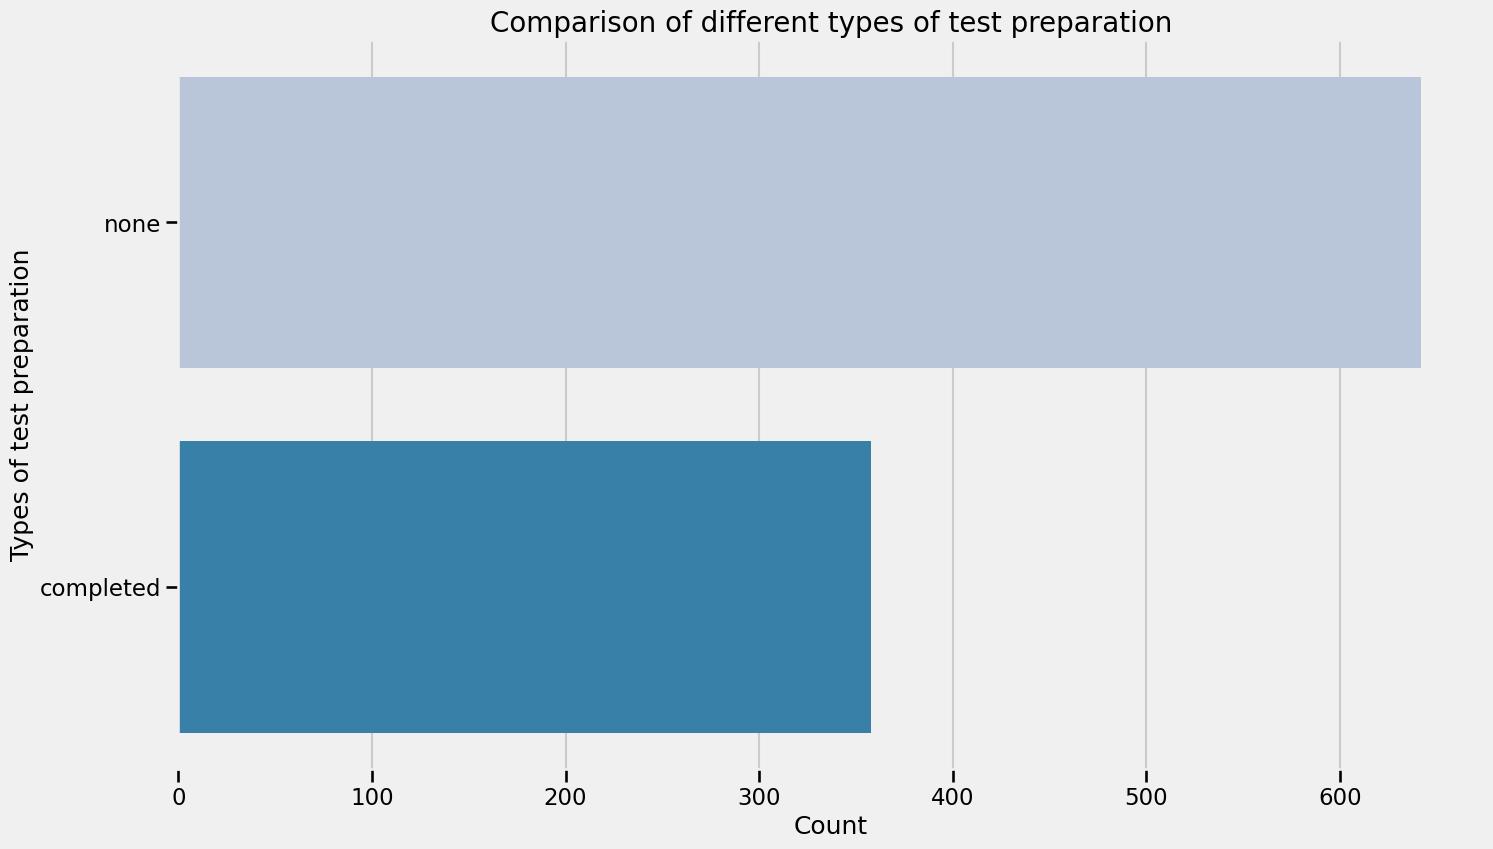

In [83]:
plt.rcParams["figure.figsize"] = (15,9)
sns.set_context('talk')
sns.countplot(df["test preparation course"], palette="PuBu")
plt.title("Comparison of different types of test preparation", fontweight=30, fontsize=20)
plt.ylabel("Types of test preparation")
plt.xlabel("Count")
plt.show()

Insight : 
* Less number of students have any completed any test preparation course.

**BIVARIATE ANALYSIS**

<Axes: xlabel='lunch', ylabel='writing score'>

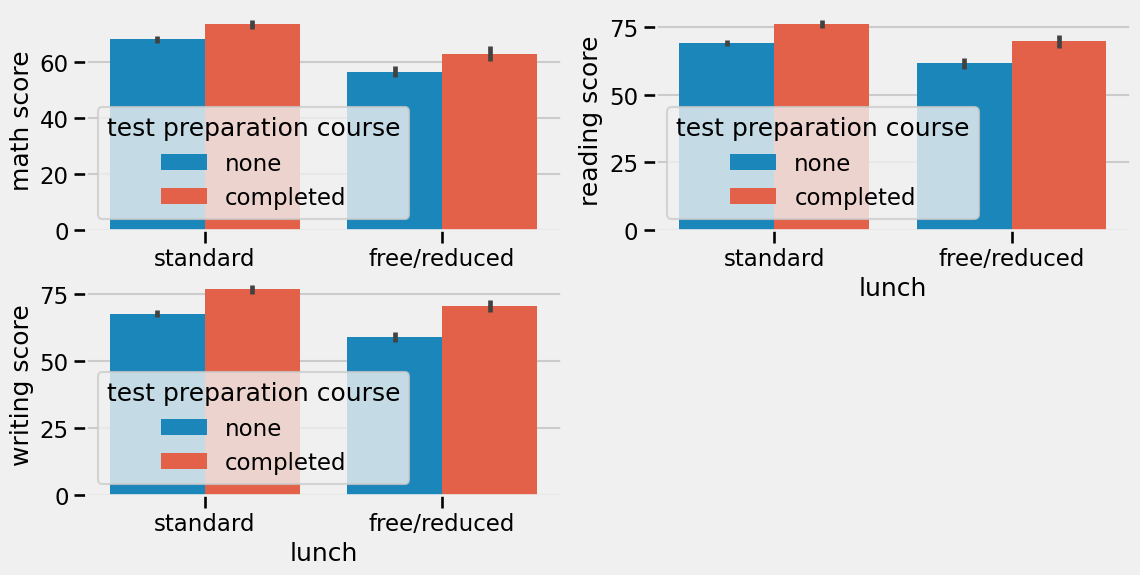

In [84]:
plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
sns.barplot(x=df["lunch"], y=df["math score"], hue=df["test preparation course"])
plt.subplot(2,2,2)
sns.barplot(x=df["lunch"], y=df["reading score"], hue=df["test preparation course"])
plt.subplot(2,2,3)
sns.barplot(x=df["lunch"], y=df["writing score"], hue=df["test preparation course"])

Insights : 
* Students who have completed the test preparation course have scored high in all three courses, irrespective of what lunch intake they had.

**4.4.6 CHECKING OUTLIERS**

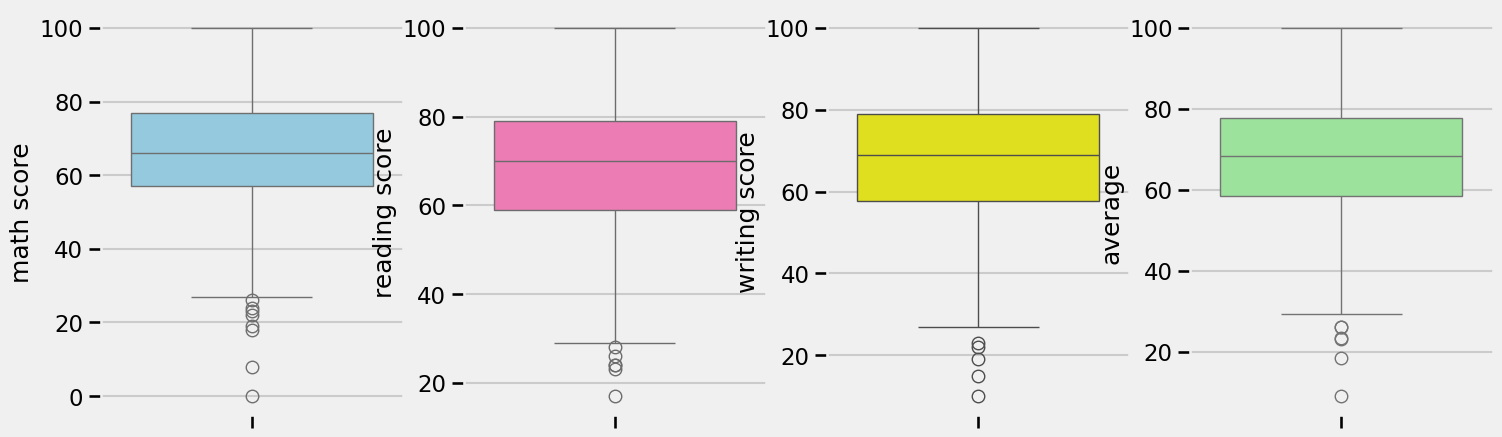

In [86]:
plt.subplots(1,4, figsize=(16,5))
plt.subplot(141)
sns.boxplot(df["math score"], color="skyblue")
plt.subplot(142)
sns.boxplot(df["reading score"], color="hotpink")
plt.subplot(143)
sns.boxplot(df["writing score"], color="yellow")
plt.subplot(144)
sns.boxplot(df["average"],color="lightgreen")
plt.show()

**4.4.7 MULTI VARIATE ANALYSIS USING PAIR PLOT**

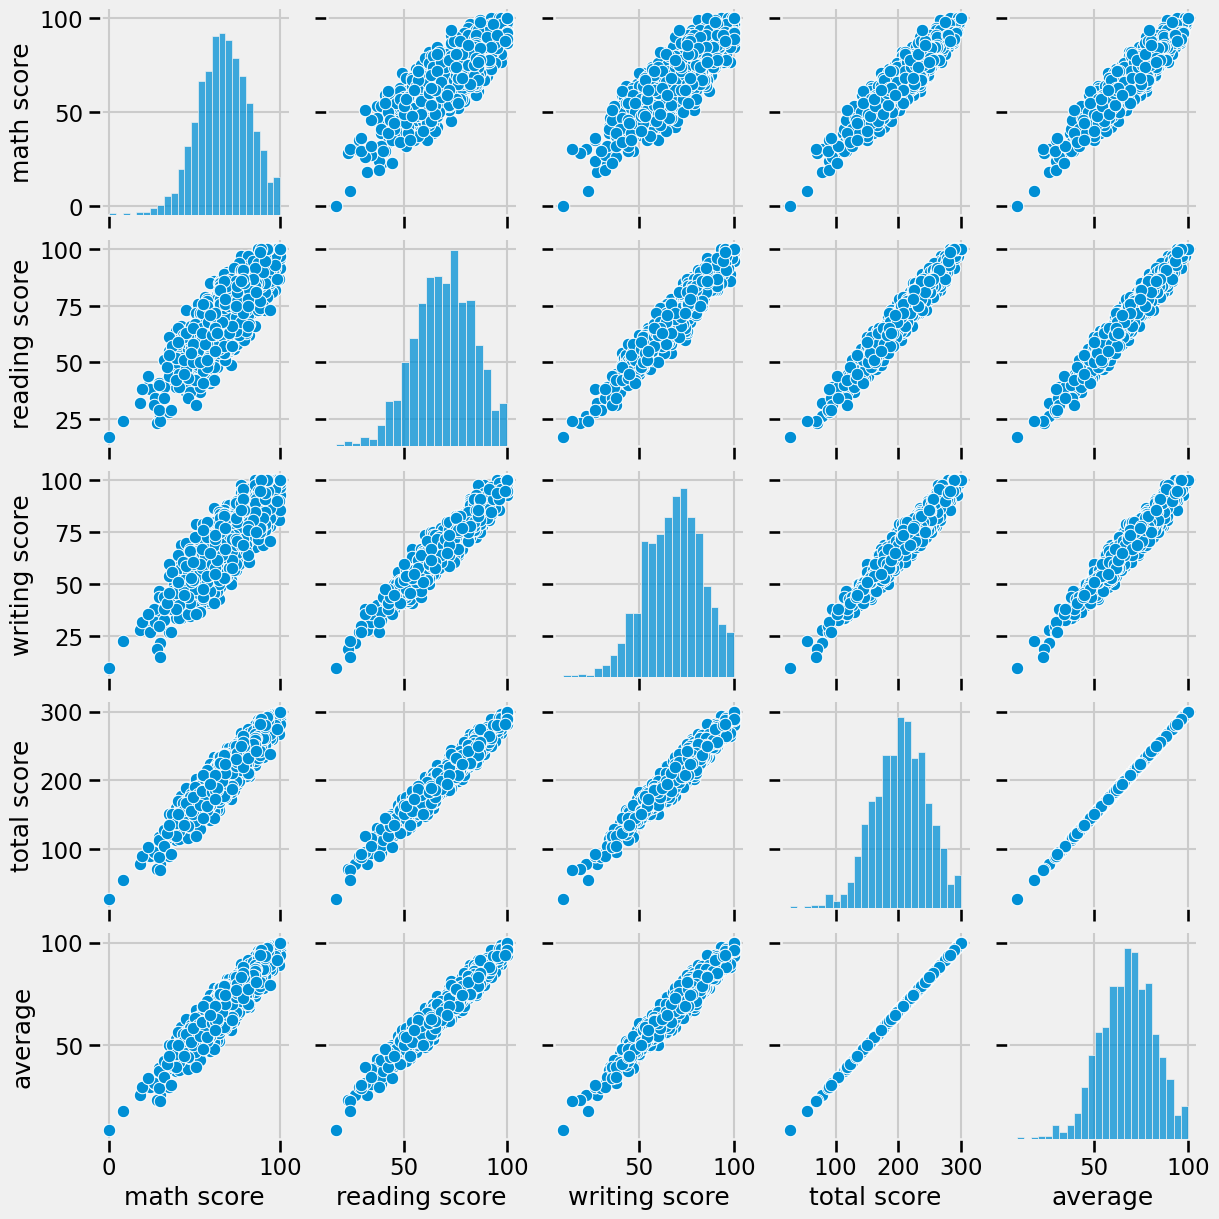

In [88]:
sns.pairplot(df)
plt.show()

Insights : 
* From the above plot, it is clear that all the scores increase linearly with each other.

#### 5. Conclusions

* Student's performance is related with lunch, race, parental level education
* Females lead in pass percentage and also are top-scorers
* Student's performance is not much related with test preparation course.
* Finishing preparation couse is beneficial.